In [1]:
import numpy as np
import duckdb
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pl.read_parquet("/kaggle/input/datasets/ykevin000/sdss-public-service-dataset/big.parquet")
df.head()

OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
datetime[μs],str,str,str,str,str,str,i64,i64,i64,f64
2024-01-01 00:00:00,"""M9W1J1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0
2024-01-01 00:00:00,"""M9W1J1""","""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0
2024-01-01 00:00:00,"""M5S2P1""","""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0
2024-01-01 00:00:00,"""M2J4R1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0
2024-01-01 00:00:00,"""M2J4R1""","""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0


# Prepare Data

- For temporal analysis: convert dates into seasons
- Drop `LOCATION_POSTAL_CODE` column; difficult to encode without API calls

In [3]:
full_df = df.with_columns(
    pl.col("OCCUPANCY_DATE").dt.month().alias("MONTH")
).with_columns(
    pl.when(pl.col("MONTH").is_in([12, 1, 2]))
      .then(pl.lit("Winter"))
      .when(pl.col("MONTH").is_in([3, 4, 5]))
      .then(pl.lit("Spring"))
      .when(pl.col("MONTH").is_in([6, 7, 8]))
      .then(pl.lit("Summer"))
      .otherwise(pl.lit("Fall"))
      .alias("SEASON")
).drop("MONTH").drop("OCCUPANCY_DATE").drop("LOCATION_POSTAL_CODE")

full_df.head()

SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE,SEASON
str,str,str,str,str,i64,i64,i64,f64,str
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0,"""Winter"""
"""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0,"""Winter"""
"""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0,"""Winter"""
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0,"""Winter"""
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0,"""Winter"""


In [4]:
numerical_cols = ["ACTUAL_CAPACITY", "OCCUPIED_CAPACITY", "UNAVAILABLE_CAPACITY", "OCCUPANCY_RATE"]
numerical_df = full_df.select(pl.col(numerical_cols))
numerical_df.head()

ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
i64,i64,i64,f64
149,149,1,1.0
57,57,0,1.0
8,8,0,1.0
67,67,16,1.0
161,161,0,1.0


# Scale Dataset

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(numerical_df.to_numpy())

# K Means Clustering

- Perform K means clustering on numerical data to ex

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=67).fit(X)
clusters = kmeans.labels_
cluster_df = full_df.with_columns(
    pl.Series("CLUSTER_ID", clusters),
    
)
cluster_df.head()

SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE,SEASON,CLUSTER_ID
str,str,str,str,str,i64,i64,i64,f64,str,i32
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",149,149,1,1.0,"""Winter""",2
"""Mixed Adult""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",57,57,0,1.0,"""Winter""",1
"""Mixed Adult""","""Shelter""","""Emergency""","""Base Program - Refugee""","""Bed Based Capacity""",8,8,0,1.0,"""Winter""",1
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Programs""","""Room Based Capacity""",67,67,16,1.0,"""Winter""",1
"""Families""","""Motel/Hotel Shelter""","""Emergency""","""Temporary Refugee Response""","""Room Based Capacity""",161,161,0,1.0,"""Winter""",2


In [7]:
category_cols = ['CAPACITY_TYPE','OVERNIGHT_SERVICE_TYPE','PROGRAM_AREA','PROGRAM_MODEL','SEASON','SECTOR']

# Temporal Analysis

- Find patterns based of seasons:
    - Winter: December, January, February
    - Spring: March, April, May
    - Summer: June, July, August,
    - Fall: September, October, November

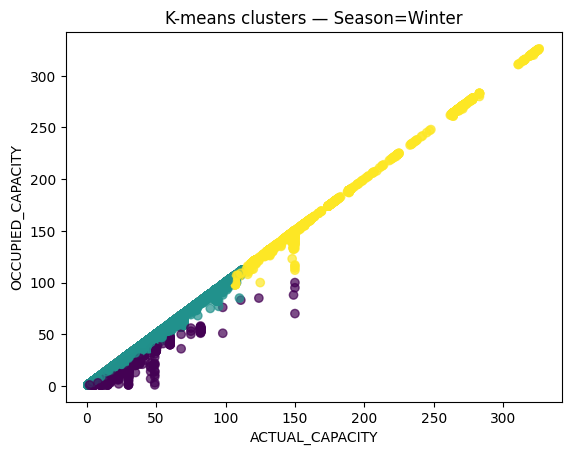

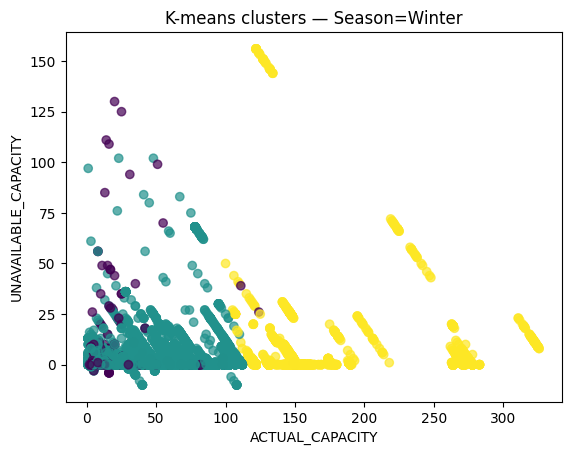

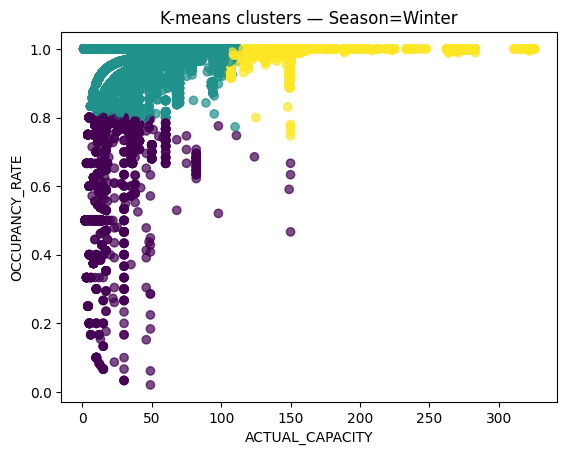

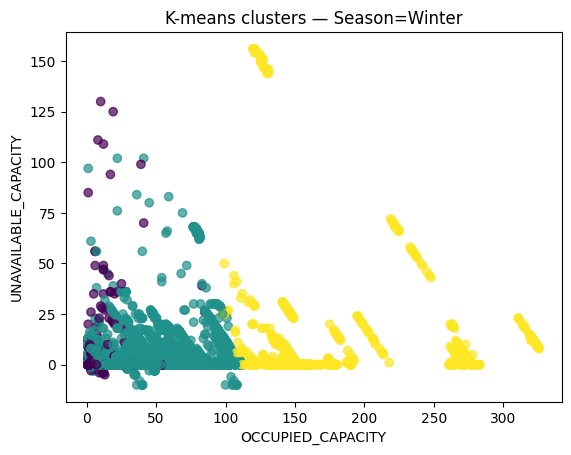

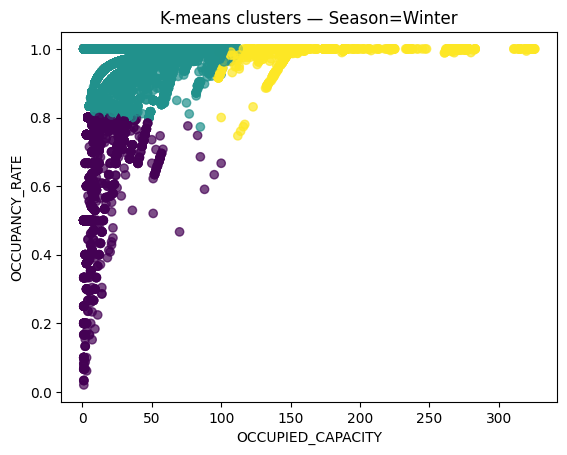

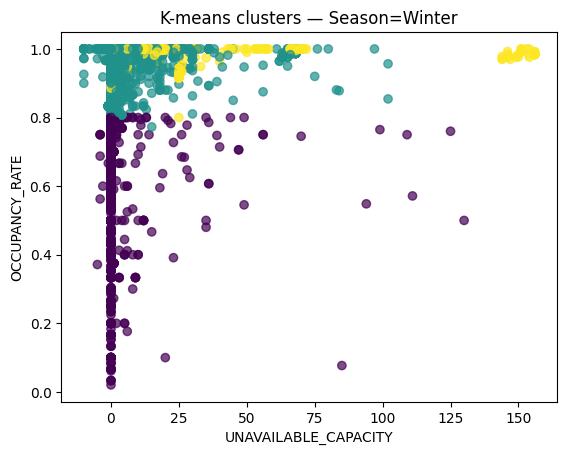

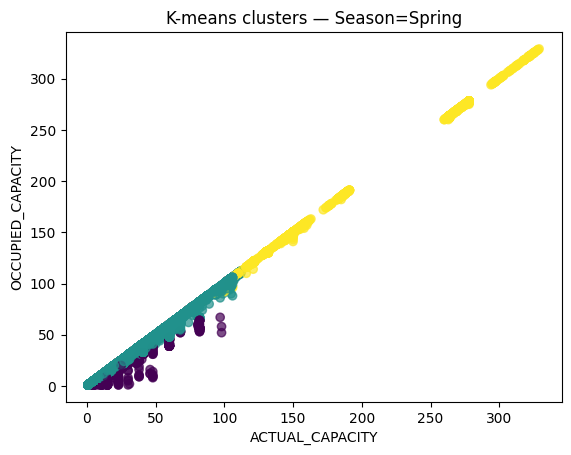

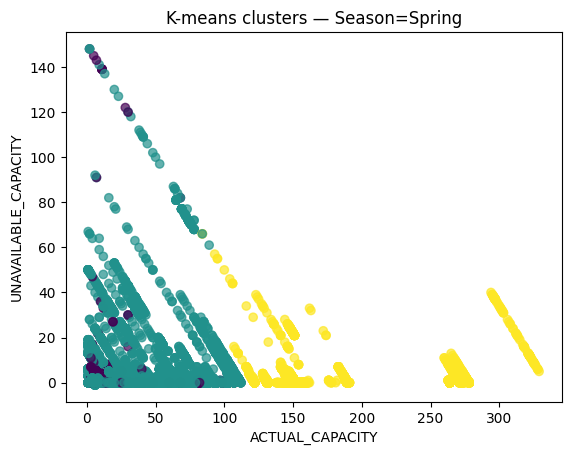

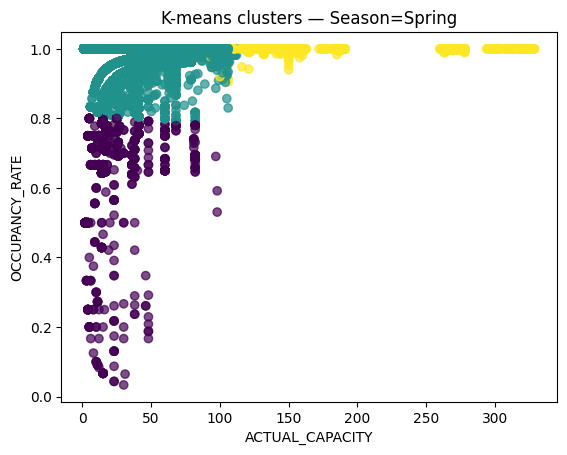

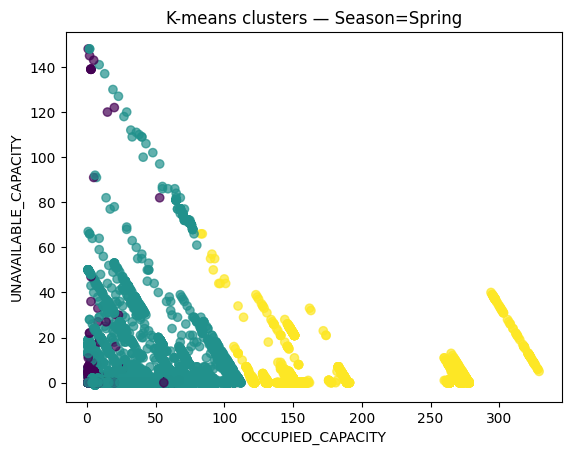

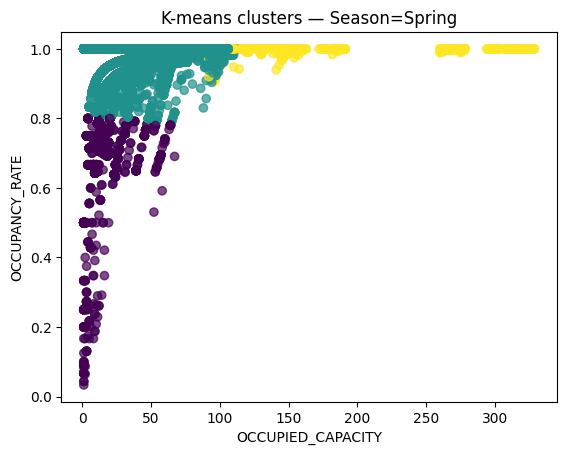

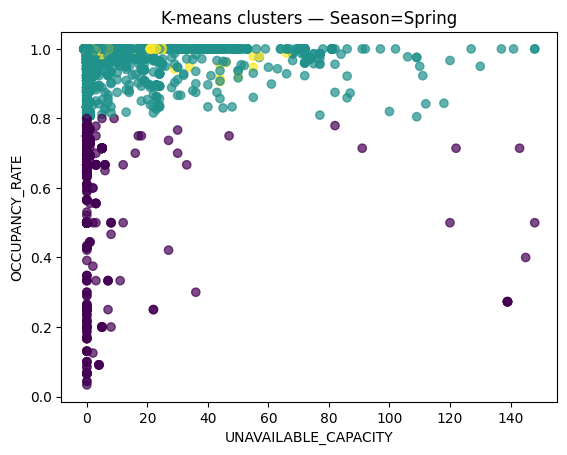

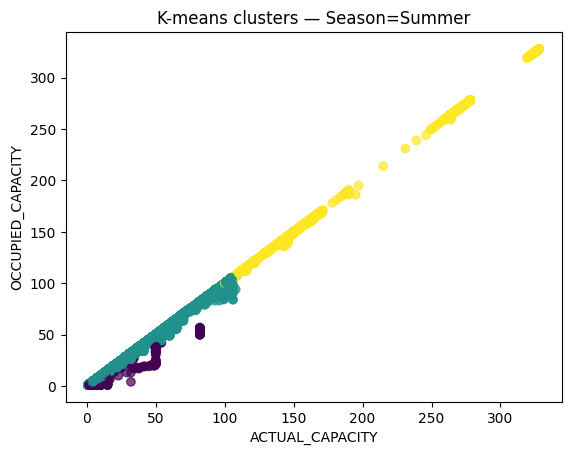

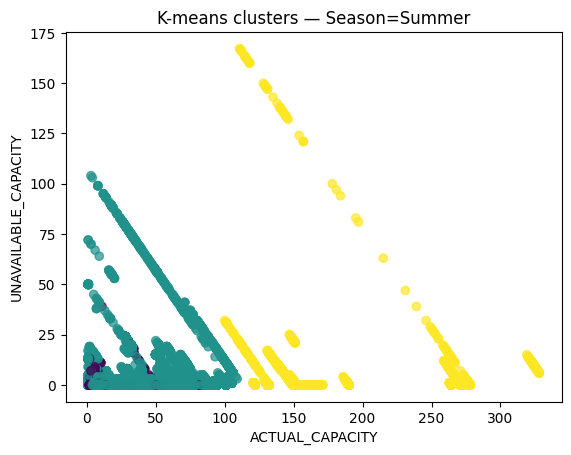

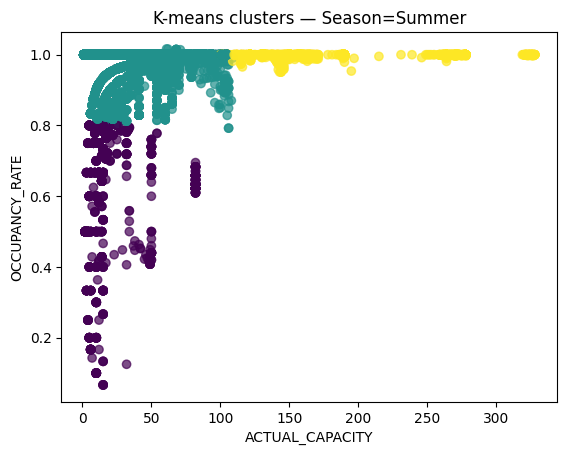

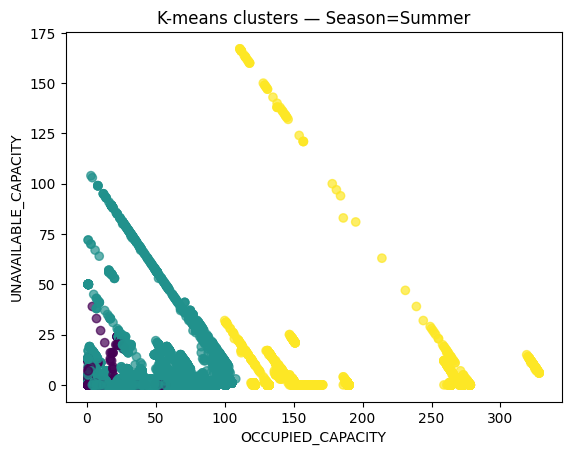

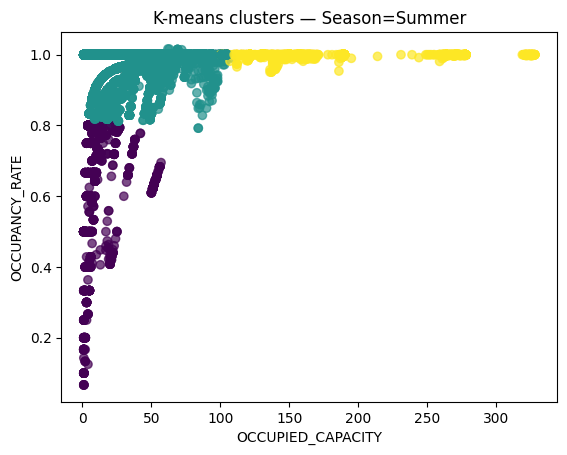

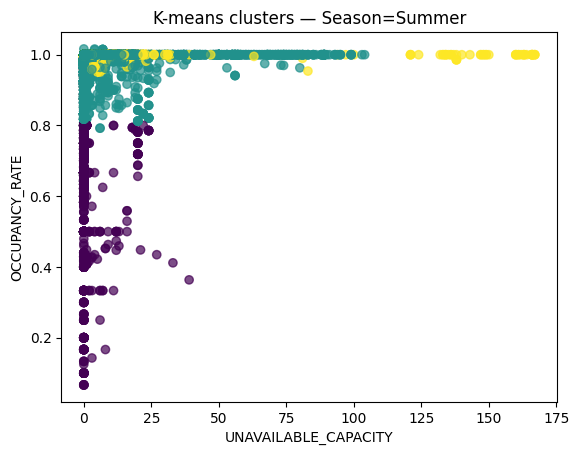

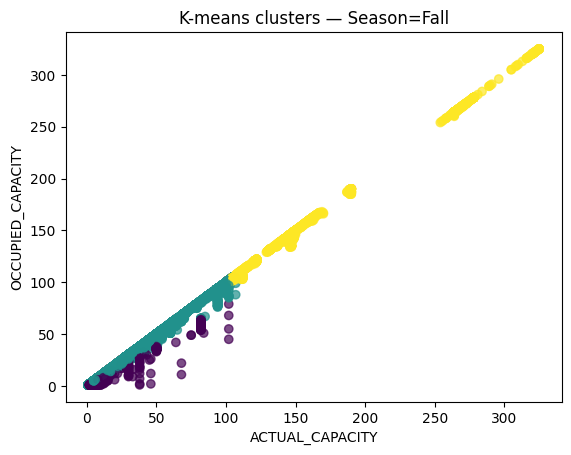

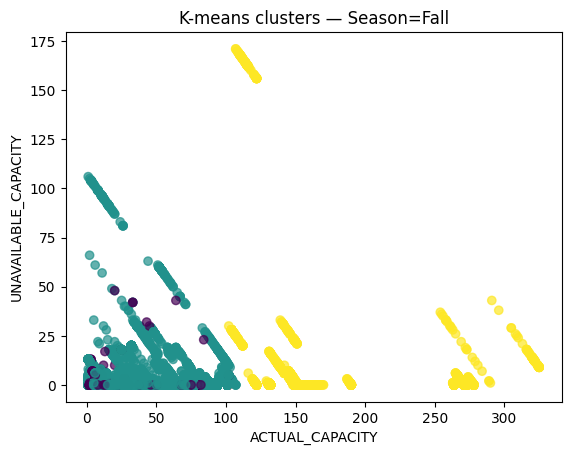

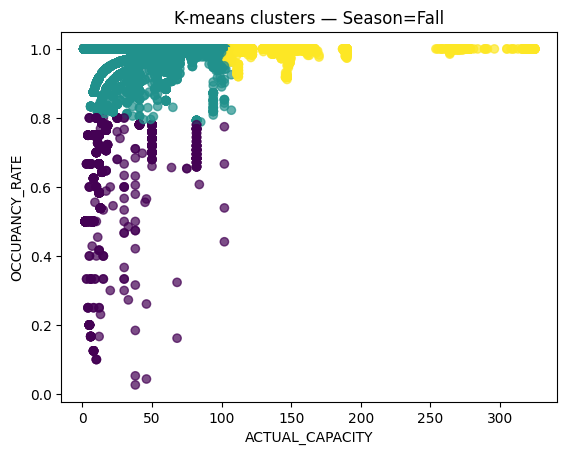

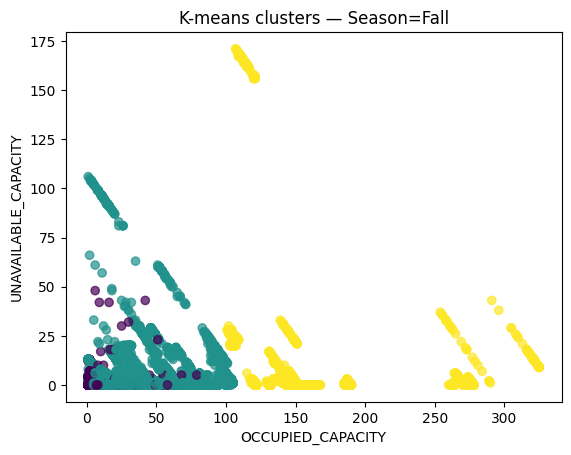

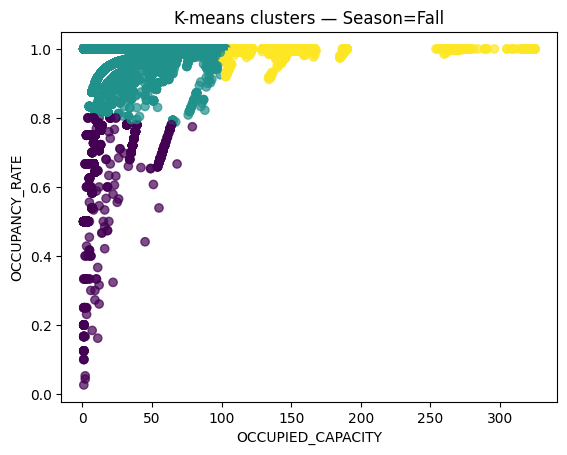

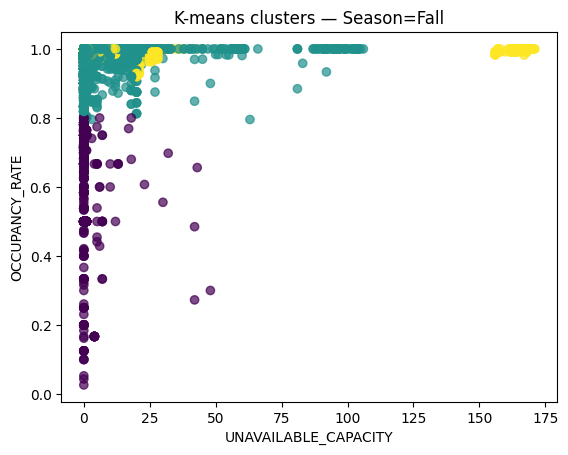

In [8]:
seasons = ["Winter", "Spring", "Summer", "Fall"]

for season in seasons:
    by_season = cluster_df.filter(pl.col("SEASON") == season)

    if by_season.height == 0:
        continue

    cluster_ids = by_season["CLUSTER_ID"]
    
    for i in range(len(numerical_cols)):
        for j in range(i + 1, len(numerical_cols)):
            x = by_season[numerical_cols[i]].to_numpy()
            y = by_season[numerical_cols[j]].to_numpy()

            plt.scatter(
                x,
                y,
                c=cluster_ids,
                alpha=0.7,
            )

            plt.xlabel(numerical_cols[i])
            plt.ylabel(numerical_cols[j])
            plt.title(f"K-means clusters — Season={season}")
            plt.show()
    

    